# 화이트 와인 품질 예측 회귀 모델 - 성능향상

[ 실습문제 : 회귀모델 정확도 향상 프로젝트 ]

## 실습 목표
현재 구현된 PyTorch 회귀 모델의 성능을 분석하고 다양한 방법으로 정확도를 향상시켜 보자.

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error

from scipy.stats import pearsonr

import random
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("현재 사용 장치:", device)

현재 사용 장치: cuda


## 2. 데이터 불러오기

```
whitewines <- read.csv("data/whitewines.csv")
```

Colab에서는 로컬 파일이 없을 수 있으므로 UCI Machine Learning Repository의 White Wine Quality 데이터를 직접 내려받습니다.
만약 직접 `whitewines.csv` 파일을 업로드해서 사용하려면 아래 코드의 `DATA_URL` 대신 업로드 파일 경로를 사용하면 됩니다.


In [2]:
import os
local_path = "data/winequality-white.csv"

os.makedirs("data", exist_ok=True)


DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

if os.path.exists(local_path):
    whitewines = pd.read_csv(local_path)
else:
    whitewines = pd.read_csv(DATA_URL, sep=';')
    
    whitewines.to_csv(local_path, index=False)

whitewines.columns = [col.replace(" ", "_") for col in whitewines.columns]

whitewines.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
X = whitewines.drop("quality", axis=1)
y = whitewines["quality"]

print("입력 특성 목록:")
print(X.columns.tolist())

print("\nX 크기:", X.shape)

print("y 크기:", y.shape)

입력 특성 목록:
['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']

X 크기: (4898, 11)
y 크기: (4898,)


In [4]:
X_train = X.iloc[:3000].copy()
X_val = X.iloc[3000:3749].copy()
X_test = X.iloc[3749:].copy()

y_train = y.iloc[:3000].copy()
y_val = y.iloc[3000:3749].copy()
y_test = y.iloc[3749:].copy()

print("X_train:", X_train.shape)
print("X_val :", X_val.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test :", y_test.shape)

X_train: (3000, 11)
X_val : (749, 11)
X_test : (1149, 11)
y_train: (3000,)
y_val: (749,)
y_test : (1149,)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("표준화 후 훈련 데이터 평균:", X_train_scaled.mean().round(4))
print("표준화 후 훈련 데이터 표준편차:", X_train_scaled.std().round(4))


표준화 후 훈련 데이터 평균: 0.0
표준화 후 훈련 데이터 표준편차: 1.0


In [6]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_tensor :", X_test_tensor.shape)
print("y_test_tensor :", y_test_tensor.shape)
print("X_val_tensor :", X_val_tensor.shape)
print("y_val_tensor :", y_val_tensor.shape)

X_train_tensor: torch.Size([3000, 11])
y_train_tensor: torch.Size([3000, 1])
X_test_tensor : torch.Size([1149, 11])
y_test_tensor : torch.Size([1149, 1])
X_val_tensor : torch.Size([749, 11])
y_val_tensor : torch.Size([749, 1])


In [7]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("미니배치 개수:", len(train_loader))

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

미니배치 개수: 47


## 회귀 모델 정의

In [8]:
class WineQualityRegressor(nn.Module):

    def __init__(self, input_dim):

        super(WineQualityRegressor, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x)

## 손실 함수와 최적화 알고리즘 설정

In [9]:
def train_model(model, optimizer, criterion, epochs, train_loader, val_loader, device):
    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    patience = 50
    patience_counter = 0

    for epoch in range(epochs):

        # ======================
        # Train phase
        # ======================
        model.train()
        epoch_train_loss = 0.0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)

            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * batch_X.size(0)

        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # ======================
        # Validation phase
        # ======================
        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)

                epoch_val_loss += loss.item() * batch_X.size(0)

        epoch_val_loss /= len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        # ======================
        # Early Stopping check
        # ======================
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0

            torch.save(model.state_dict(), "best_model.pth")
        else:
            patience_counter += 1

        # patience 초과 시 종료
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        # ======================
        # Logging
        # ======================
        if (epoch + 1) % 50 == 0 or (epoch + 1) == epochs:
            print(
                f"Epoch [{epoch+1:3d}/{epochs}] "
                f"Train Loss: {epoch_train_loss:.4f} | "
                f"Val Loss: {epoch_val_loss:.4f}"
            )

    return train_losses, val_losses

In [10]:
model = WineQualityRegressor(X_train_tensor.shape[1]).to(device)

print(model)

criterion = nn.MSELoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

train_losses, val_losses = train_model(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    epochs=2000, 
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

WineQualityRegressor(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Epoch [ 50/2000] Train Loss: 0.6309 | Val Loss: 0.5607
Epoch [100/2000] Train Loss: 0.4918 | Val Loss: 0.5739
Early stopping triggered at epoch 114


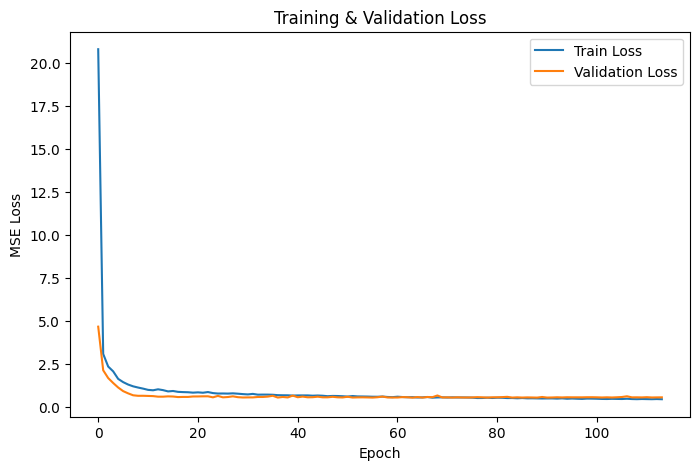

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.show()

## 테스트 데이터 예측  



In [12]:
def predict_model(model, X_test, device):
    model.eval()
    
    with torch.no_grad():
        X_test_device = X_test.to(device)

        test_predictions = model(X_test_device)

        test_predictions = test_predictions.cpu().numpy().flatten()
        
    return test_predictions

In [13]:
predictions = predict_model(
    model=model, 
    X_test=X_test_tensor, 
    device=device
)

actual_values = y_test.values

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred):
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("MSE :", mse)
    print("RMSE :", rmse)
    print("MAE :", mae)
    print("R2 :", r2)
    print("=" * 40)

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

In [15]:
evaluate_regression(actual_values, predictions)

MSE : 0.3946937024593353
RMSE : 0.6282465300018261
MAE : 0.5012736320495605
R2 : 0.3518145680427551


{'mse': 0.3946937024593353,
 'rmse': np.float64(0.6282465300018261),
 'mae': 0.5012736320495605,
 'r2': 0.3518145680427551}